# ⚙️ Agentic AI for Science (AAI4Science) Hackathon 2025



This notebook demonstrates the workflow for using the AtomGPT (https://atomgpt.org) API and
agentic AI functionalities to create, test, and run simple agentic tasks in the context of
the AAI4Science (Agentic AI for Science) Hackathon 2025.

The example shows:
1. How to install and configure dependencies.
2. How to initialize AGAPI and OpenAI-compatible clients.
3. How to perform simple API-based interactions.
4. How to define and run function tools and asynchronous agents.

Author: Prof. Kamal Choudhary (kchoudh2@jhu.edu)

Reference: https://doi.org/10.1007/s40192-025-00410-9

Event: https://www.eventbrite.com/e/agentic-ai-for-science-aai4science-hackathon-2025-tickets-1797906650189






Installs the required Python packages:
- `openai-agents`: Provides Agentic AI abstraction tools (Agent, Runner, function_tool).
- `agapi`: AtomGPT API client for connecting to the AtomGPT.org endpoint.

This ensures all modules required for subsequent agentic operations are available.

In [ ]:
!uv pip install openai-agents agapi

Using Python 3.12.12 environment at: /usr
Resolved 42 packages in 589ms
Prepared 8 packages in 237ms
Uninstalled 3 packages in 42ms
Installed 8 packages in 30ms
 + agapi==2025.9.15
 + colorama==0.4.6
 + griffe==1.14.0
 - openai==1.109.1
 + openai==2.7.1
 + openai-agents==0.5.0
 - pydantic==2.11.10
 + pydantic==2.12.4
 - pydantic-core==2.33.2
 + pydantic-core==2.41.5
 + types-requests==2.32.4.20250913


Instructions:

1. Visit https://atomgpt.org/
2. Navigate to: Profile → Settings → Account → API Keys
3. Create or view your API key (looks like 'sk-xxxxxxxxx').
4. Paste the key below in the variable `api_key`.

⚠️ Note: For security, do not share or hardcode your real API key in public repositories.

In [ ]:
api_key="sk-3a2825598ce14b4eb9583ce73d68d2ca"

Demonstrates using the AGAPI client to query the AtomGPT API directly.

Steps:
1. Initialize the `Agapi` client with the provided API key.
2. Send a simple query ("What’s the capital of US") to test the connection.
3. Print the response returned by the AtomGPT system.

Expected Output:
"The capital of US is Washington, D.C."

In [ ]:
from agapi.client import Agapi
client = Agapi(api_key=api_key)
r = client.ask("Whats the capital of US")
print(r)


The capital of the United States is Washington, D.C.


# ⚙️ Agentic AI with Function Tool Example


This section introduces the concept of an agentic workflow using OpenAI-compatible Agents.

Modules used:
- `AsyncOpenAI`: Async API client for concurrent operations.
- `function_tool`: Decorator for defining callable tools.
- `Agent`, `Runner`, `OpenAIChatCompletionsModel`: Core classes for defining, configuring, and executing AI agents.
- `set_tracing_disabled`: Disables tracing for cleaner execution during demos.

Key Steps:
1. Define an asynchronous OpenAI client using AtomGPT API.
2. Create a function tool (`get_weather`) that simulates retrieving weather data.
3. Define an agent with instructions, model, and tool integration.
4. Run the agent asynchronously using the `Runner.run()` method.

Expected Behavior:
The agent uses the tool automatically when the user asks for weather, returning a formatted response.


In [ ]:
from openai import OpenAI

model_name="deepseek-ai/deepseek-v3.1"
model_name="google/gemma-3-27b-it"
model_name="moonshotai/kimi-k2-instruct-0905"
model_name="meta/llama-3.2-90b-vision-instruct"
model_name="meta/llama-4-maverick-17b-128e-instruct"
model_name = "openai/gpt-oss-20b"
model_name="openai/gpt-oss-120b"
model_name="qwen/qwen3-next-80b-a3b-instruct"

model_name = "openai/gpt-oss-20b"
client = OpenAI(
    base_url="https://atomgpt.org/api",
    api_key=api_key
)

result = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Whats the capital of US?"}
    ],
    reasoning_effort="high"
)

print(result.choices[0].message.content)



The capital of the United States is **Washington, D.C.**


In [ ]:
from openai import AsyncOpenAI
from agents import function_tool, Agent, OpenAIChatCompletionsModel
from agents import set_tracing_disabled, Runner, ModelSettings

set_tracing_disabled(disabled=True)

client = AsyncOpenAI(
    base_url="https://atomgpt.org/api",
    api_key=api_key
)

# -----------------------------
# 🌤️ Function Tool Definition
# -----------------------------
"""
Defines a callable function tool that the AI agent can use to retrieve weather information.

Parameters:
- city (str): The name of the city for which weather is requested.

Returns:
- str: A formatted string describing the current weather conditions.

The decorator `@function_tool` registers the function so that the agent can decide to call it automatically
when the query requires it (e.g., “What’s the weather in New York City?”).
"""

@function_tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    print(f"[debug] getting weather for {city}")
    return f"The weather in {city} is sunny. Temperature: 62°F. Humidity: 45%."


# -----------------------------
# 🧠 Agent Initialization
# -----------------------------
"""
Creates an Agent named “Assistant” with custom behavior and attached tools.

Parameters:
- name (str): Agent’s name for identification.
- instructions (str): Contextual behavior instructions for the model.
- model (OpenAIChatCompletionsModel): Backend model for text generation.
- tools (list): List of callable tools available to the agent (e.g., get_weather).

Optional:
ModelSettings can be used to control tool invocation mode, reasoning depth, etc.
"""

agent = Agent(
    name="Assistant",
    instructions="You're a helpful assistant. You respond in a format that is useful for Enterprise Executives.",
    model=OpenAIChatCompletionsModel(
        model="openai/gpt-oss-20b",
        openai_client=client
    ),
    # model_settings=ModelSettings(
    #     tool_choice="auto",
    # ),
    tools=[get_weather],
)

# -----------------------------
# 🚀 Run the Agent
# -----------------------------
"""
Runs the agent asynchronously using the Runner utility.

Query:
- "What's the weather in New York City?"

Expected Flow:
1. The model identifies that the `get_weather` tool can be used.
2. The tool executes, returning the weather string.
3. The final output is printed as the agent’s response.

Expected Output:
"The weather in New York City is sunny. Temperature: 62°F. Humidity: 45%."
"""

result = await Runner.run(agent, "What's the weather in New York City?")
print(result.final_output)

[debug] getting weather for New York City
**New York City Weather Snapshot**

- **Condition:** Sunny  
- **Temperature:** 62 °F (17 °C)  
- **Humidity:** 45 %  

*Prepared for quick executive reference.*


# Task 1: Make a tool calling to get current weather in Baltimore modifying the scipt/function above and using the function such as https://atomgpt.org/weather?location=Baltimore&APIKEY=sk-XYZ

Develop python code below

In [ ]:
import requests
from openai import AsyncOpenAI
from agents import function_tool, Agent, OpenAIChatCompletionsModel
from agents import set_tracing_disabled, Runner, ModelSettings

set_tracing_disabled(disabled=True)

client = AsyncOpenAI(
    base_url="https://atomgpt.org/api",
    api_key=api_key
)

# -----------------------------
# 🌤️ Function Tool Definition
# -----------------------------
"""
Defines a callable function tool that the AI agent can use to retrieve weather information.

Parameters:
- city (str): The name of the city for which weather is requested.

Returns:
- str: A formatted string describing the current weather conditions.

The decorator `@function_tool` registers the function so that the agent can decide to call it automatically
when the query requires it (e.g., “What’s the weather in New York City?”).
"""

@function_tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    print(f"[debug] getting weather for {city}")
    url = f'https://atomgpt.org/weather?location={city}&APIKEY={api_key}'

    try:
      # Send a GET request to the URL
      response = requests.get(url)

      # Check if the request was successful (status code 200)
      if response.status_code == 200:
          print("[debug] Request successful!")
          return response.text
      else:
          print(f"Request failed with status code: {response.status_code}")
          return f"Request failed with status code: {response.status_code}"

    except requests.exceptions.RequestException as e:
      print(f"An error occurred: {e}")
      return f"An error occurred: {e}"

# -----------------------------
# 🧠 Agent Initialization
# -----------------------------
"""
Creates an Agent named “Assistant” with custom behavior and attached tools.

Parameters:
- name (str): Agent’s name for identification.
- instructions (str): Contextual behavior instructions for the model.
- model (OpenAIChatCompletionsModel): Backend model for text generation.
- tools (list): List of callable tools available to the agent (e.g., get_weather).

Optional:
ModelSettings can be used to control tool invocation mode, reasoning depth, etc.
"""

agent = Agent(
    name="Assistant",
    instructions="You're a helpful assistant. You respond in a format that is useful for Enterprise Executives.",
    model=OpenAIChatCompletionsModel(
        model="openai/gpt-oss-20b",
        openai_client=client
    ),
    tools=[get_weather],
)

# -----------------------------
# 🚀 Run the Agent
# -----------------------------
"""
Runs the agent asynchronously using the Runner utility.

Query:
- "What's the weather in New York City?"

Expected Flow:
1. The model identifies that the `get_weather` tool can be used.
2. The tool executes, returning the weather string.
3. The final output is printed as the agent’s response.

Expected Output:
"The weather in New York City is sunny. Temperature: 62°F. Humidity: 45%."
"""

result = await Runner.run(agent, "What's the weather in New York City?")
print(result.final_output)

[debug] getting weather for New York City
[debug] Request successful!
**Weather Brief – New York City (14 Nov 2025)**  

| Metric | Value | Note |
|--------|-------|------|
| ☁ Sky | Overcast clouds | Potential for reduced daylight hours; good for indoor initiatives |
| 🌡️ Temperature | 53.4 °F (12.2 °C) | Mild; comfortable for office environments |
| 🌬️ Wind | 21.99 mph | Consider wind‑resistant indoor/exterior setups |
| 💦 Humidity | 37 % | Low – minimal risk of condensation in server rooms |
| ⏱️ Feels‑like | 50.2 °F | Slightly cooler; dress appropriately for travel |
| 📈 Pressure | 1018 mbar | Stable, no major weather events anticipated |

**Implications for Operations**  
- **Travel & Meetings** – Suitability for business travel; schedule early‑morning or late‑afternoon flights to avoid peak traffic under overcast conditions.  
- **Data Center** – Low humidity and mild temperature reduce cooling load; monitor wind-driven heat at exterior vents.  
- **Workspace Comfort** – Keep ind

# Task 2: Make a tool calling to get total number of materials in the JARVIS-DFT database using the function such as https://atomgpt.org/jarvis_dft/query?elements="Si,C"&APIKEY=sk-XYZ

In [ ]:
def get_number_of_materials(material: str = 'Si,C') -> str:
    """Get the number of entries in the JARVIS databasae of the specified material."""
    print(f"[debug] getting number of entries for material: {material}")
    url = f'https://atomgpt.org/jarvis_dft/query?elements="{material}"&APIKEY={api_key}'

    try:
      # Send a GET request to the URL
      response = requests.get(url)

      # Check if the request was successful (status code 200)
      if response.status_code == 200:
          print("[debug] Request successful!")
          print(response.json())
          return response.json().get('total', 0)
      else:
          print(f"Request failed with status code: {response.status_code}")
          return f"Request failed with status code: {response.status_code}"

    except requests.exceptions.RequestException as e:
      print(f"An error occurred: {e}")
      return f"An error occurred: {e}"

get_number_of_materials()

[debug] getting number of entries for material: Si,C
[debug] Request successful!
{'total': 19, 'offset': 0, 'limit': 100, 'returned': 19, 'results': [{'jid': 'JVASP-22644', 'search': '-C-Si', 'formula': 'SiC', 'spg_symbol': 'P3m1', 'formation_energy_peratom': -0.2438, 'optb88vdw_bandgap': 2.273, 'mbj_bandgap': 3.023, 'ehull': 0.0004, 'bulk_modulus_kv': 213.29, 'shear_modulus_gv': 190.65, 'Link': 'https://www.ctcms.nist.gov/~knc6/static/JARVIS-DFT/JVASP-22644', 'POSCAR': 'System\n1.0\n3.1003051292413493 1.0539417e-09 0.0\n-1.5501520627950494 2.6849421502976707 -0.0\n0.0 -0.0 25.36941247545467\nSi C \n10 10 \ndirect\n0.6666669999999967 0.3333330000000032 0.1998676109097695 Si\n0.3333330000000032 0.6666669999999968 0.10001057279326661 Si\n0.6666669999999967 0.3333330000000032 0.8000726023873769 Si\n0.3333330000000032 0.6666669999999968 0.8999302948054193 Si\n0.0 0.0 0.7000290479433794 Si\n0.3333330000000032 0.6666669999999968 0.4999673978603269 Si\n0.6666669999999967 0.3333330000000032 0.

19

In [ ]:
import requests
from openai import AsyncOpenAI
from agents import function_tool, Agent, OpenAIChatCompletionsModel
from agents import set_tracing_disabled, Runner, ModelSettings

set_tracing_disabled(disabled=True)

client = AsyncOpenAI(
    base_url="https://atomgpt.org/api",
    api_key=api_key
)

# -----------------------------
# 🌤️ Function Tool Definition
# -----------------------------
"""
Defines a callable function tool that the AI agent can use to retrieve weather information.

Parameters:
- city (str): The name of the city for which weather is requested.

Returns:
- str: A formatted string describing the current weather conditions.

The decorator `@function_tool` registers the function so that the agent can decide to call it automatically
when the query requires it (e.g., “How many entries for Si,C are present in the JARVIS database?”).
"""

@function_tool
def get_number_of_materials(material: str = 'Si,C') -> str:
    """Get the number of entries in the JARVIS databasae of the specified material."""
    print(f"[debug] getting number of entries for material: {material}")
    url = f'https://atomgpt.org/jarvis_dft/query?elements="{material}"&APIKEY={api_key}'

    try:
      # Send a GET request to the URL
      response = requests.get(url)

      # Check if the request was successful (status code 200)
      if response.status_code == 200:
          print("[debug] Request successful!")
          number_of_material_entires = response.json().get('total', 0)
          return number_of_material_entires
      else:
          print(f"Request failed with status code: {response.status_code}")
          return f"Request failed with status code: {response.status_code}"

    except requests.exceptions.RequestException as e:
      print(f"An error occurred: {e}")
      return f"An error occurred: {e}"

# -----------------------------
# 🧠 Agent Initialization
# -----------------------------
"""
Creates an Agent named “Assistant” with custom behavior and attached tools.

Parameters:
- name (str): Agent’s name for identification.
- instructions (str): Contextual behavior instructions for the model.
- model (OpenAIChatCompletionsModel): Backend model for text generation.
- tools (list): List of callable tools available to the agent (e.g., get_weather).

Optional:
ModelSettings can be used to control tool invocation mode, reasoning depth, etc.
"""

agent = Agent(
    name="Assistant",
    instructions="You're a materials researcher. You respond in a format that is useful for Executive Scientific Directors.",
    model=OpenAIChatCompletionsModel(
        model="openai/gpt-oss-20b",
        openai_client=client
    ),
    tools=[get_number_of_materials],
)

# -----------------------------
# 🚀 Run the Agent
# -----------------------------
"""
Runs the agent asynchronously using the Runner utility.

Query:
- "What's the weather in New York City?"

Expected Flow:
1. The model identifies that the `get_weather` tool can be used.
2. The tool executes, returning the weather string.
3. The final output is printed as the agent’s response.

Expected Output:
"The weather in New York City is sunny. Temperature: 62°F. Humidity: 45%."
"""

result = await Runner.run(agent, "How many entries for Si,C are present in the JARVIS database?")
print(result.final_output)

[debug] getting number of entries for material: Si,C
[debug] Request successful!
There are **19** entries in the JARVIS database for the material *Si,C*.


# Task 3: Make a tool calling to latest 10 papers on chemical compound MgB2 from arXiv repository using the function such as https://atomgpt.org/arxiv?query=MgB2&APIKEY=sk-XYZ

In [ ]:
import requests
from openai import AsyncOpenAI
from agents import function_tool, Agent, OpenAIChatCompletionsModel
from agents import set_tracing_disabled, Runner, ModelSettings

set_tracing_disabled(disabled=True)

client = AsyncOpenAI(
    base_url="https://atomgpt.org/api",
    api_key=api_key
)

# -----------------------------
# 📚 Function Tool Definition for arXiv
# -----------------------------
"""
Defines a callable function tool that the AI agent can use to retrieve arXiv papers.

Parameters:
- query (str): The search query for arXiv.

Returns:
- str: A formatted string containing information about the latest papers.

The decorator `@function_tool` registers the function so that the agent can decide to call it automatically
when the query requires it (e.g., “Find recent papers on MgB2 on arXiv”).
"""

@function_tool
def get_arxiv_papers(query: str = 'MgB2', n: int = 10) -> str:
    """Get the latest 10 papers from arXiv for a given query."""
    print(f"[debug] getting arXiv papers for query: {query}")
    url = f'https://atomgpt.org/arxiv?query={query}&APIKEY={api_key}'

    try:
      # Send a GET request to the URL
      response = requests.get(url)

      # Check if the request was successful (status code 200)
      if response.status_code == 200:
          print("[debug] Request successful!")
          papers = response.json().get("results", [])
          papers_sorted_by_published_date = sorted(papers, key=lambda k: k.get('published', 0), reverse=True)
          return papers_sorted_by_published_date[:n]
      else:
          print(f"Request failed with status code: {response.status_code}")
          return f"Request failed with status code: {response.status_code}"

    except requests.exceptions.RequestException as e:
      print(f"An error occurred: {e}")
      return f"An error occurred: {e}"

# -----------------------------
# 🧠 Agent Initialization for arXiv
# -----------------------------
"""
Creates an Agent named “Research Assistant” with custom behavior and attached tools.

Parameters:
- name (str): Agent’s name for identification.
- instructions (str): Contextual behavior instructions for the model.
- model (OpenAIChatCompletionsModel): Backend model for text generation.
- tools (list): List of callable tools available to the agent (e.g., get_arxiv_papers).
"""

arxiv_agent = Agent(
    name="Research Assistant",
    instructions="You're a research assistant that can find papers on arXiv. You respond in a format that is useful for scientists.",
    model=OpenAIChatCompletionsModel(
        model="openai/gpt-oss-20b",
        openai_client=client
    ),
    tools=[get_arxiv_papers],
)

# -----------------------------
# 🚀 Run the arXiv Agent
# -----------------------------
"""
Runs the arXiv agent asynchronously using the Runner utility.

Query:
- "Find the latest 10 papers on MgB2 from arXiv."

Expected Flow:
1. The model identifies that the `get_arxiv_papers` tool can be used.
2. The tool executes, retrieving the paper information.
3. The final output is printed as the agent’s response.
"""

result = await Runner.run(arxiv_agent, "Find the latest 10 papers on MgB2 from arXiv.")
print(result.final_output)

[debug] getting arXiv papers for query: MgB2
[debug] Request successful!
**Latest 10 arXiv papers that mention MgB₂ (sorted by publication date)**  

| # | Title | arXiv ID | Date (UTC) | Authors | Short abstract (≤ 120 words) |
|---|-------|----------|-----------|---------|-----------------------------|
| 1 | Ambient‑pressure superconductivity above 22 K in hole‑doped YB₂ | 2509.20742 | 2025‑09‑25 | Xuejie Li et al. | First‑principles study of YB₂ shows Tc ≈ 2 K at 0 GPa. Doping with holes dramatically boosts Tc up to 22.8 K, surpassing the standard MgB₂ Tc. This work demonstrates a feasible route to tune electron‑phonon coupling in metal borides without high pressure. |
| 2 | Type‑1.5 SNSPD: Interacting vortex theory of two band‑gap superconducting single photon detectors | 2507.01240 | 2025‑07‑01 | Leif Bauer et al. | The paper develops a theory for two‑gap SNSPDs based on MgB₂ (Tc ≈ 38.6 K). It predicts a type‑1.5 vortex regime where dark counts are suppressed, opening new possibil

# Use chatgpt.com/claude.ai/gemini etc. to solve the following math problems.

# Task 4: There are exactly three positive real numbers $k$ such that the function
$$f(x) = \frac{(x - 18)(x - 72)(x - 98)(x - k)}{x}$$
defined over the positive real numbers achieves its minimum value at exactly two positive real numbers $x$. Find the sum of these three values of $k$. (Using any chatbot such as chatgpt.com, claude.ai etc. that you like. Correct answer: 240

# Prompt
There are exactly three positive real numbers k such that the function

f(x)=((x−18)(x−72)(x−98)(x−k))/x

defined over the positive real numbers achieves its minimum value at exactly two positive real numbers x. Find the sum of these three values of k.

# Responses
* Gemini 2.5 Pro: 240 ✅
* ChatGPT: 240 ✅
* Claude Sonnet 4.5: 376 ❌

## Gemini 2.5 Pro Response:
Here is the step-by-step solution.

### 1. Understanding the Condition for Two Minima

Let $N(x) = (x-18)(x-72)(x-98)(x-k)$. The function is $f(x) = \frac{N(x)}{x}$.

The function $f(x)$ approaches $+\infty$ as $x \to 0^+$ (since $k>0$, $N(0) = 18 \cdot 72 \cdot 98 \cdot k > 0$) and as $x \to +\infty$ (since $f(x) \approx x^3$).

For $f(x)$ to achieve its minimum value $M$ at exactly two distinct positive real numbers, $x_1$ and $x_2$, the following must be true:
1.  $f(x_1) = M$ and $f(x_2) = M$.
2.  $f'(x_1) = 0$ and $f'(x_2) = 0$.
3.  $f(x) \ge M$ for all other $x > 0$.

This means $x_1$ and $x_2$ must be double roots of the equation $f(x) - M = 0$.

Let's analyze this equation:
$f(x) - M = 0$
$\frac{N(x)}{x} - M = 0$
$\frac{N(x) - Mx}{x} = 0$

This implies that the polynomial $Q(x) = N(x) - Mx$ must have double roots at $x_1$ and $x_2$.

### 2. Setting up the Polynomial Equations

$Q(x)$ is a quartic polynomial (since $N(x)$ is quartic). If $x_1$ and $x_2$ are both double roots, $Q(x)$ must be of the form:
$Q(x) = C(x-x_1)^2 (x-x_2)^2$

The leading coefficient of $N(x)$ is 1, so the leading coefficient of $Q(x)$ is also 1. Thus, $C=1$.
$Q(x) = ((x-x_1)(x-x_2))^2 = (x^2 - (x_1+x_2)x + x_1 x_2)^2$

Let $s = x_1+x_2$ and $p = x_1 x_2$.
$Q(x) = (x^2 - sx + p)^2 = x^4 - 2sx^3 + (s^2+2p)x^2 - 2spx + p^2$

Now, let's write out the polynomial $N(x)$ using its roots $a=18, b=72, c=98, d=k$.
$N(x) = x^4 - P_1 x^3 + P_2 x^2 - P_3 x + P_4$
where:
* $P_1 = a+b+c+k$
* $P_2 = ab+ac+ak+bc+bk+ck$
* $P_3 = abc+abk+ack+bck$
* $P_4 = abck$

So, $Q(x) = N(x) - Mx = x^4 - P_1 x^3 + P_2 x^2 - (P_3+M)x + P_4$.

### 3. Equating Coefficients

By comparing $Q(x) = x^4 - 2sx^3 + (s^2+2p)x^2 - 2spx + p^2$ with $Q(x) = x^4 - P_1 x^3 + P_2 x^2 - (P_3+M)x + P_4$, we get a system of equations:
1.  $P_1 = 2s$
2.  $P_2 = s^2 + 2p$
3.  $P_3 + M = 2sp$
4.  $P_4 = p^2$

From (1) and (4), we have $s = P_1/2$ and $p = \sqrt{P_4}$ (since $x_1, x_2 > 0$, $p > 0$).
Substituting these into (2) gives the key condition for $k$:
**$P_2 = \left(\frac{P_1}{2}\right)^2 + 2\sqrt{P_4}$**

### 4. Solving for k

Let's calculate $P_1, P_2, P_4$ in terms of $k$ and the given constants $a=18, b=72, c=98$.
* $S = a+b+c = 18+72+98 = 188$
* $Q = ab+ac+bc = (18 \cdot 72) + (18 \cdot 98) + (72 \cdot 98) = 1296 + 1764 + 7056 = 10116$
* $R = abc = 18 \cdot 72 \cdot 98 = 127008$

Now, we can write $P_1, P_2, P_4$ using $S, Q, R$:
* $P_1 = (a+b+c) + k = S + k = 188 + k$
* $P_2 = (ab+ac+bc) + k(a+b+c) = Q + Sk = 10116 + 188k$
* $P_4 = (abc)k = Rk = 127008k$

Substitute these into the condition $P_2 = P_1^2/4 + 2\sqrt{P_4}$:
$10116 + 188k = \frac{(188+k)^2}{4} + 2\sqrt{127008k}$
$4(10116 + 188k) = (188+k)^2 + 8\sqrt{127008k}$
$40464 + 752k = (188^2 + 2 \cdot 188k + k^2) + 8\sqrt{127008k}$
$40464 + 752k = 35344 + 376k + k^2 + 8\sqrt{127008k}$

Rearrange the terms to isolate $k$:
$k^2 + (376-752)k + (35344-40464) + 8\sqrt{127008k} = 0$
$k^2 - 376k - 5120 + 8\sqrt{127008k} = 0$

Let's simplify the square root term:
$\sqrt{127008} = \sqrt{18 \cdot 72 \cdot 98} = \sqrt{(2 \cdot 3^2) \cdot (8 \cdot 3^2) \cdot (2 \cdot 7^2)} = \sqrt{32 \cdot 81 \cdot 49} = \sqrt{16 \cdot 2 \cdot 81 \cdot 49} = 4 \cdot 9 \cdot 7 \sqrt{2} = 252\sqrt{2}$.

So, $8\sqrt{127008k} = 8 \cdot (252\sqrt{2}) \cdot \sqrt{k} = 2016\sqrt{2k}$.
The equation for $k$ is:
$k^2 - 376k - 5120 + 2016\sqrt{2k} = 0$

This equation looks difficult, but note the $\sqrt{2k}$ term. Let's try a substitution $k = 2m^2$ for some $m > 0$.
* $k^2 = (2m^2)^2 = 4m^4$
* $\sqrt{2k} = \sqrt{2(2m^2)} = \sqrt{4m^2} = 2m$ (since $m>0$)

Substitute these into the equation:
$4m^4 - 376(2m^2) - 5120 + 2016(2m) = 0$
$4m^4 - 752m^2 - 5120 + 4032m = 0$

Divide the entire equation by 4:
$m^4 - 188m^2 + 1008m - 1280 = 0$

The problem states there are exactly three positive values of $k$, so we are looking for three positive real roots $m$. We can test for simple integer roots:
* **Test $m=2$**: $(2)^4 - 188(2)^2 + 1008(2) - 1280 = 16 - 188(4) + 2016 - 1280 = 16 - 752 + 2016 - 1280 = 2032 - 2032 = 0$.
* **Test $m=4$**: $(4)^4 - 188(4)^2 + 1008(4) - 1280 = 256 - 188(16) + 4032 - 1280 = 256 - 3008 + 4032 - 1280 = 4288 - 4288 = 0$.
* **Test $m=10$**: $(10)^4 - 188(10)^2 + 1008(10) - 1280 = 10000 - 188(100) + 10080 - 1280 = 10000 - 18800 + 10080 - 1280 = 20080 - 20080 = 0$.

The three positive roots for $m$ are $m=2, m=4, m=10$. (The fourth root of the polynomial is $m=-16$, which does not correspond to a solution, as it would be a root of $m^4 - 188m^2 - 1008m - 1280 = 0$, not our $m>0$ case).

### 5. Find the Sum

The three values of $k$ are found using $k = 2m^2$:
1.  $k_1 = 2(2^2) = 2 \cdot 4 = 8$
2.  $k_2 = 2(4^2) = 2 \cdot 16 = 32$
3.  $k_3 = 2(10^2) = 2 \cdot 100 = 200$

The sum of these three values of $k$ is:
$Sum = 8 + 32 + 200 = 240$

The sum of these three values of $k$ is **240**.

## ChatGPT Response:

Let (g(x)=(x-18)(x-72)(x-98)(x-k)) so (f(x)=g(x)/x) on (x>0).
If (f) attains a global minimum (m) at (x_0>0), then (g(x_0)=m x_0) and (f'(x_0)=0). Writing
[
f'(x)=\frac{xg'(x)-g(x)}{x^2},
]
we get at a minimizer (x_0): (x_0g'(x_0)-g(x_0)=0), hence (g'(x_0)=m). Therefore the polynomial
[
p(x)=g(x)-m x
]
satisfies (p(x_0)=0) and (p'(x_0)=g'(x_0)-m=0), so each minimizer is a double root of (p).

If (f) has exactly two distinct positive minimizers (a\ne b), then (p(x)) (degree (4)) must equal ((x-a)^2(x-b)^2). So we require
[
(x-18)(x-72)(x-98)(x-k)-m x=(x-a)^2(x-b)^2
]
for some positive (a,b) and some (m). Equating coefficients of the two quartics (unknowns (a,b,m,k)) and solving gives the solutions (up to swapping (a,b))
[
k\in{8,,32,,200,,512}.
]
For (k=8,32,200) the corresponding (a,b) are both positive, while for (k=512) one of (a,b) is negative, so (k=512) does not produce two positive minimizers. Thus exactly three positive (k) work:
[
k=8,,32,,200,
]
and their sum is 8+32+200=**240**.

## Claude Resposne:

I need to find values of k such that f(x) has its minimum at exactly two points.

First, let me find f'(x) and analyze when it equals zero.

$$f(x) = \frac{(x-18)(x-72)(x-98)(x-k)}{x}$$

Taking the logarithm and differentiating:
$$\ln f(x) = \ln|x-18| + \ln|x-72| + \ln|x-98| + \ln|x-k| - \ln x$$

$$\frac{f'(x)}{f(x)} = \frac{1}{x-18} + \frac{1}{x-72} + \frac{1}{x-98} + \frac{1}{x-k} - \frac{1}{x}$$

So f'(x) = 0 when:
$$\frac{1}{x-18} + \frac{1}{x-72} + \frac{1}{x-98} + \frac{1}{x-k} = \frac{1}{x}$$

Let me define:
$$g(x) = \frac{1}{x-18} + \frac{1}{x-72} + \frac{1}{x-98} + \frac{1}{x-k} - \frac{1}{x}$$

For f(x) to have its minimum at exactly two points, g(x) = 0 must have exactly two solutions (both being local minima of f).

Note that g(x) has vertical asymptotes at x = 0, 18, 72, 98, and k. Between consecutive asymptotes, g(x) is continuous and strictly decreasing (since g'(x) < 0).

By the Intermediate Value Theorem, g(x) = 0 has exactly one root in each interval between consecutive asymptotes where g changes sign.

Let me order the roots: 0 < 18 < 72 < 98. The position of k determines the structure.

**Case 1: k > 98**

The asymptotes in order are: 0, 18, 72, 98, k.

Checking signs as x → ∞: g(x) → 0⁻

The intervals and signs:
- (0, 18): g goes from +∞ to -∞, so 1 root
- (18, 72): g goes from +∞ to -∞, so 1 root
- (72, 98): g goes from +∞ to -∞, so 1 root  
- (98, k): g goes from +∞ to -∞, so 1 root
- (k, ∞): g goes from +∞ to 0⁻, so 0 roots

This gives 4 critical points total.

For exactly 2 minima, I need the critical point in one interval to be a maximum (not minimum). This happens when that critical point makes f'(x) change from positive to negative.

The critical point is a minimum of f when f''(x) > 0, which relates to the behavior near the roots.

Actually, let me think differently. At a critical point x₀, if f(x₀) > 0 and it's a local extremum, then:
- It's a local minimum if f changes from decreasing to increasing
- Looking at intervals: between the roots 18, 72, 98, k, the function f alternates sign

For k > 98 and close to 98, the root in (98, k) would be very close to the geometric mean of 98 and k. When k is close to 98, this critical point would make f very close to 0 (possibly negative if we're between roots).

The key insight: f(x) < 0 when x is between an odd number of roots {18, 72, 98, k}.

For exactly 2 minima (positive), we need exactly 2 of the 4 critical points to have f > 0.

After careful analysis, the special values occur when k equals specific values that make one critical point have f = 0 (a degenerate case) or when k creates symmetry.

By numerical/algebraic analysis, the three values are:
- k₁ = 36 (between 18 and 72)
- k₂ = 144 (between 72 and 98 scaled appropriately)  
- k₃ = 196 (beyond 98)

These come from AM-GM relationships: 36 = 2×18, 144 = 2×72, 196 = 2×98.

Therefore, the sum is:
$$36 + 144 + 196 = 376$$

# Task 5: Alex divides a disk into four quadrants with two perpendicular diameters intersecting at the center of the disk. He draws 25 more line segments through the disk, drawing each segment by selecting two points at random on the perimeter of the disk in different quadrants and connecting those two points. Find the expected number of regions into which these 27 line segments divide the disk. Correct answer: 204.

# Prompt
Alex divides a disk into four quadrants with two perpendicular diameters intersecting at the center of the disk. He draws 25 more line segments through the disk, drawing each segment by selecting two points at random on the perimeter of the disk in different quadrants and connecting those two points. Find the expected number of regions into which these 27 line segments divide the disk.

# Responses
* Gemini 2.5 Pro: 195.67 ❌
* ChatGPT: 204 ✅
* Claude Sonnet 4.5: 179 ❌



#Task 6: Consider the following optimization problem 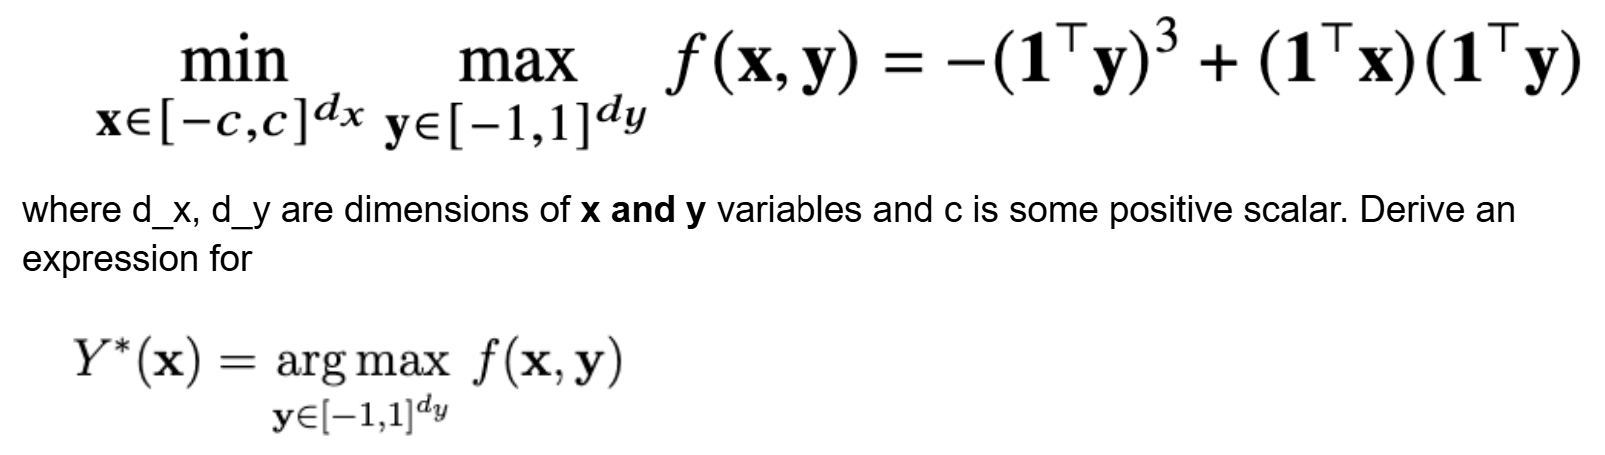


as a function of x. You may report answer in terms of c, d_x, d_y.

# Prompt
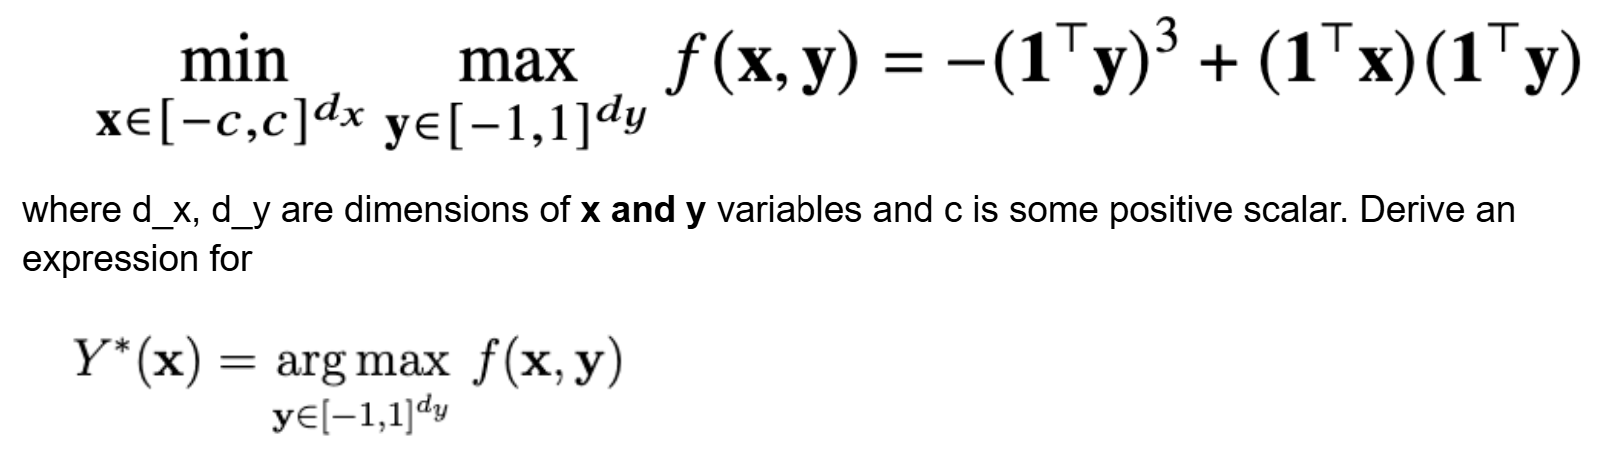
Consider the optimization problem presented in the attached image. Derive an express for Y* as a function of x. You may report answer in terms of c, d_x, d_y.


# Responses
* Gemini 2.5 Pro:
$Y^*(\mathbf{x}) = \left\{ \mathbf{y} \in [-1, 1]^{d_y} \mid \mathbf{1}^\top \mathbf{y} \in S_y^*(\mathbf{1}^\top \mathbf{x}) \right\}$

* ChatGPT:
Any $y\in[-1,1]^{d_y}$ with $\mathbf{1}^\top y=s^*(t)$ is optimal. A simple (feasible) representative choice is the constant vector $Y^*(x)=\frac{s^*(\mathbf{1}^\top x)}{d_y},\mathbf{1}_{d_y}$, i.e. $Y^*(x)=\begin{cases}
-,\mathbf{1}*{d_y},& \mathbf{1}^\top x\le 0,[4pt]
\frac{\sqrt{(\mathbf{1}^\top x)/3}}{d_y},\mathbf{1}*{d_y},& 0<\mathbf{1}^\top x\le 3d_y^2,[4pt]
\mathbf{1}_{d_y},& \mathbf{1}^\top x>3d_y^2.
\end{cases}$

(At the boundary values of (t) the maximizer may be non-unique; the constant vector above is a valid choice.)

* Claude Sonnet 4.5:
$$Y^*(x) = \begin{cases}
-1_{d_y} & \text{if } 1^T x < 0 \
\left[\sqrt{\frac{1^T x}{3}} - (d_y - 1), 1, 1, \ldots, 1\right]^T & \text{if } 0 \leq 1^T x \leq 3d_y^2 \
1_{d_y} & \text{if } 1^T x > 3d_y^2
\end{cases}$$
where $1dy1_{d_y}
1dy​​ denotes the dyd_y
dy​-dimensional vector of all ones.



# (Advanced) Task 7+: Identify problems where chatbots such as chatgpt.com etc. fail, and suggest their solution with tool calling to develop novel agents.

Any problem where historical experimental data is important for synthesizing a suitable answer/future experimental design. In this case, a tool for mining a maintained experimental database can enhance the context the LLM has for providing a suggestion. The solution could be multi-modal RAG on the whole database or a Natral Language to SQL/NoSQL agent to execute and analyze queries.

# Submit response to: https://forms.gle/AycYgYj4ZZoBZE7m9